# Python第6次作业

使用“数据4.3”数据文件（详情已在第4章习题部分中介绍），Profit contribution为利润贡献度，作为响应变量；Net interest income为净利息收入、Intermediate income为中间业务收入、Deposit and finance daily为日均存款加理财之和，均作为特征变量，构建决策树回归算法模型。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import cohen_kappa_score
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LinearRegression

## 1. 变量设置及数据处理


In [2]:
data = pd.read_csv("../data/数据13.1.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   credit       700 non-null    int64  
 1   age          700 non-null    int64  
 2   education    700 non-null    int64  
 3   workyears    700 non-null    float64
 4   resideyears  700 non-null    float64
 5   income       700 non-null    float64
 6   debtratio    700 non-null    float64
 7   creditdebt   700 non-null    float64
 8   otherdebt    700 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 49.3 KB


In [3]:
data.isnull().values.any()

False

In [4]:
data.credit.value_counts()

credit
0    517
1    183
Name: count, dtype: int64

In [5]:
data.credit.value_counts(normalize=True)

credit
0    0.738571
1    0.261429
Name: proportion, dtype: float64

In [6]:
# 将样本示例全集分割为训练样本和测试样本
X = data.iloc[:, 1:]  # 设置特征变量
y = data.iloc[:, 0]   # 设置响应变量
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=10
)

---

## 2. 未考虑成本-复杂度剪枝的决策树回归算法模型

### 2.1 分裂准则为信息熵

In [7]:
model = DecisionTreeClassifier(criterion="entropy", max_depth=2, random_state=10)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8714285714285714

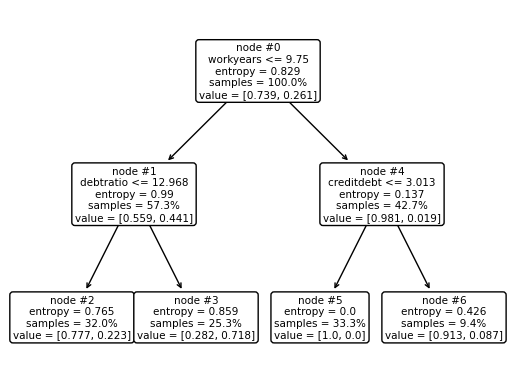

In [8]:
plot_tree(
    model,
    feature_names=X.columns,
    node_ids=True,
    impurity=True,
    proportion=True,
    rounded=True,
    precision=3,
)
plt.savefig("out1.pdf")  # 有效解决显示不清晰的问题

In [9]:
prob = model.predict_proba(X_test)
prob[:5]

array([[1.        , 0.        ],
       [0.77707006, 0.22292994],
       [0.28225806, 0.71774194],
       [0.28225806, 0.71774194],
       [0.91304348, 0.08695652]])

In [10]:
pred = model.predict(X_test)
pred[:5]

array([0, 0, 1, 1, 0])

In [11]:
print(confusion_matrix(y_test, pred))

[[139  16]
 [ 11  44]]


In [12]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       155
           1       0.73      0.80      0.77        55

    accuracy                           0.87       210
   macro avg       0.83      0.85      0.84       210
weighted avg       0.88      0.87      0.87       210



In [13]:
cohen_kappa_score(y_test, pred)  # 计算kappa得分

0.676923076923077

### 2.2 分裂准则为基尼指数

In [14]:
model = DecisionTreeClassifier(
    criterion="gini", max_depth=2, random_state=10
)  # 采用基尼系数作为分裂准则，指定决策树的最大深度为2，设定随机数种子为100
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8571428571428571

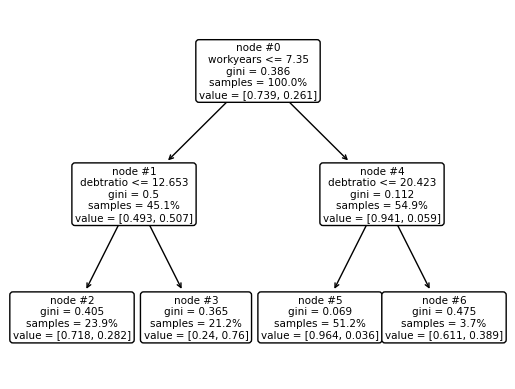

In [15]:
plot_tree(
    model,
    feature_names=X.columns,
    node_ids=True,
    impurity=True,
    proportion=True,
    rounded=True,
    precision=3,
)
plt.savefig("out2.pdf")

---

## 3. 构建考虑成本-复杂度剪枝的决策树回归算法模型

In [16]:
model = DecisionTreeClassifier(random_state=10)
path = model.cost_complexity_pruning_path(X_train, y_train)
print("模型复杂度参数：", max(path.ccp_alphas))  # 输出最大的模型复杂度参数
print("模型不纯度：", max(path.impurities))  # 输出最大的模型不纯度

模型复杂度参数： 0.0990821190369432
模型不纯度： 0.38597251145356104


---

## 4. 绘制图形观察"叶节点总均方误差随alpha值变化情况"

In [19]:
# 解决图表中负号不显示问题
# plt.rcParams['axes.unicode_minus'] = False
# 解决图表中中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']

Text(0.5, 1.0, '叶节点总不纯度随alpha值变化情况')

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

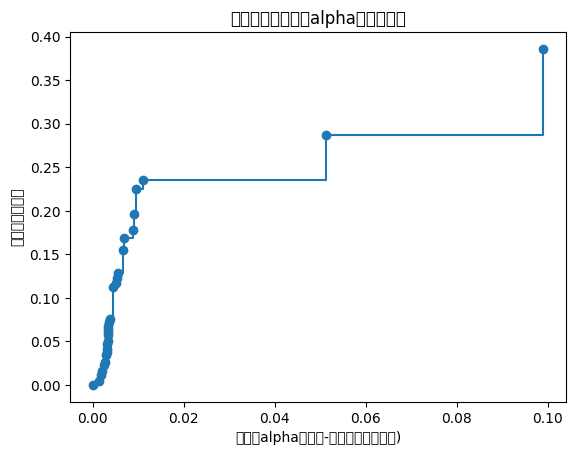

In [20]:
fig, ax = plt.subplots()
# plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决图表中中文显示问题
ax.plot(path.ccp_alphas, path.impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("有效的alpha（成本-复杂度剪枝参数值)")
ax.set_ylabel("叶节点总不纯度")
ax.set_title("叶节点总不纯度随alpha值变化情况")

---

## 5. 绘制图形观察“节点数和树的深度随alpha值变化情况”

In [23]:
models = []
for ccp_alpha in path.ccp_alphas:
    model = DecisionTreeClassifier(random_state=10, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    models.append(model)
print(
    "最后一棵决策时的节点数为: {} ;其alpha值为: {}".format(
        models[-1].tree_.node_count, path.ccp_alphas[-1]
    )
)  # 输出最path.ccp_alphas中最后一个值，即修剪整棵树的alpha值，只有一个节点

最后一棵决策时的节点数为: 1 ;其alpha值为: 0.0990821190369432


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

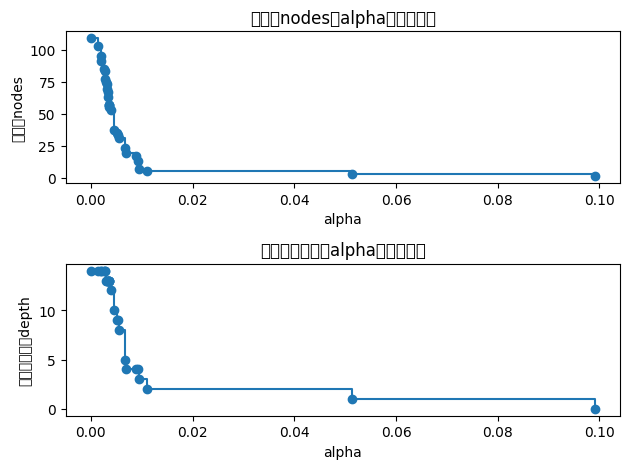

In [24]:
node_counts = [model.tree_.node_count for model in models]
depth = [model.tree_.max_depth for model in models]
fig, ax = plt.subplots(2, 1)
ax[0].plot(path.ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("节点数nodes")
ax[0].set_title("节点数nodes随alpha值变化情况")
ax[1].plot(path.ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("决策树的深度depth")
ax[1].set_title("决策树的深度随alpha值变化情况")
fig.tight_layout()

---

## 6. 绘制图形观察“训练样本和测试样本的拟合优度随alpha值变化情况”

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/home/zql/.local/lib/python3.8/site-packages/I

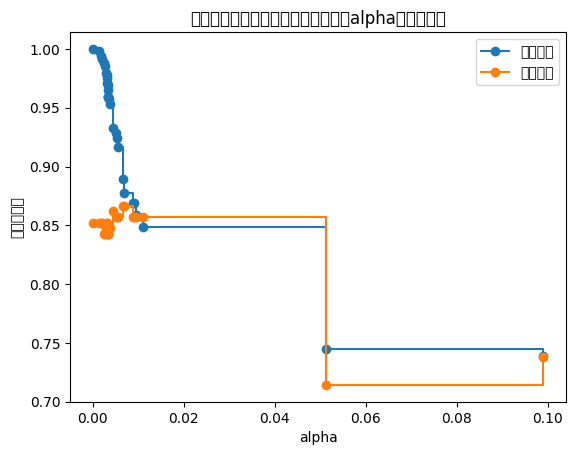

In [26]:
train_scores = [model.score(X_train, y_train) for model in models]
test_scores = [model.score(X_test, y_test) for model in models]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("预测准确率")
ax.set_title("训练样本和测试样本的预测准确率随alpha值变化情况")
ax.plot(
    path.ccp_alphas, train_scores, marker="o", label="训练样本", drawstyle="steps-post"
)
ax.plot(
    path.ccp_alphas, test_scores, marker="o", label="测试样本", drawstyle="steps-post"
)
ax.legend()
plt.show()

---

## 7. 通过10折交叉验证法寻求最优alpha值并开展特征变量重要性水平分析

In [27]:
param_grid = {"ccp_alpha": path.ccp_alphas}
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
model = GridSearchCV(DecisionTreeClassifier(random_state=10), param_grid, cv=kfold)
model.fit(X_train, y_train)
print("最优alpha值：", model.best_params_)

最优alpha值： {'ccp_alpha': 0.004534462760155709}


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

最优预测准确率： 0.861904761904762


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

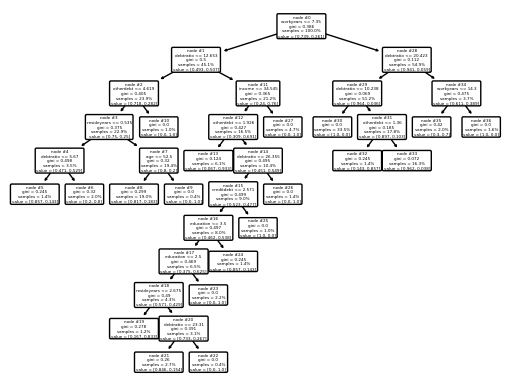

In [28]:
model = model.best_estimator_
print("最优预测准确率：", model.score(X_test, y_test))
plot_tree(
    model,
    feature_names=X.columns,
    node_ids=True,
    impurity=True,
    proportion=True,
    rounded=True,
    precision=3,
)
plt.savefig("out3.pdf")

---

## 8. 最优模型拟合效果图形展示

---

## 9. 构建线性回归算法模型进行对比。